In [2]:
%pip install opencv-python numpy matplotlib


  Using cached numpy-2.3.2-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached pillow-11.3.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (9.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 2.9 MB/s  0:00:13m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 3.2 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 2.9 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 3.0 MB/s  0:00:00 eta 0:00:01
Using cached pillow-11.3.0-cp313-cp313-macosx_11_0_arm64.whl (4.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [matplotlib]9 [matplotlib]on]
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


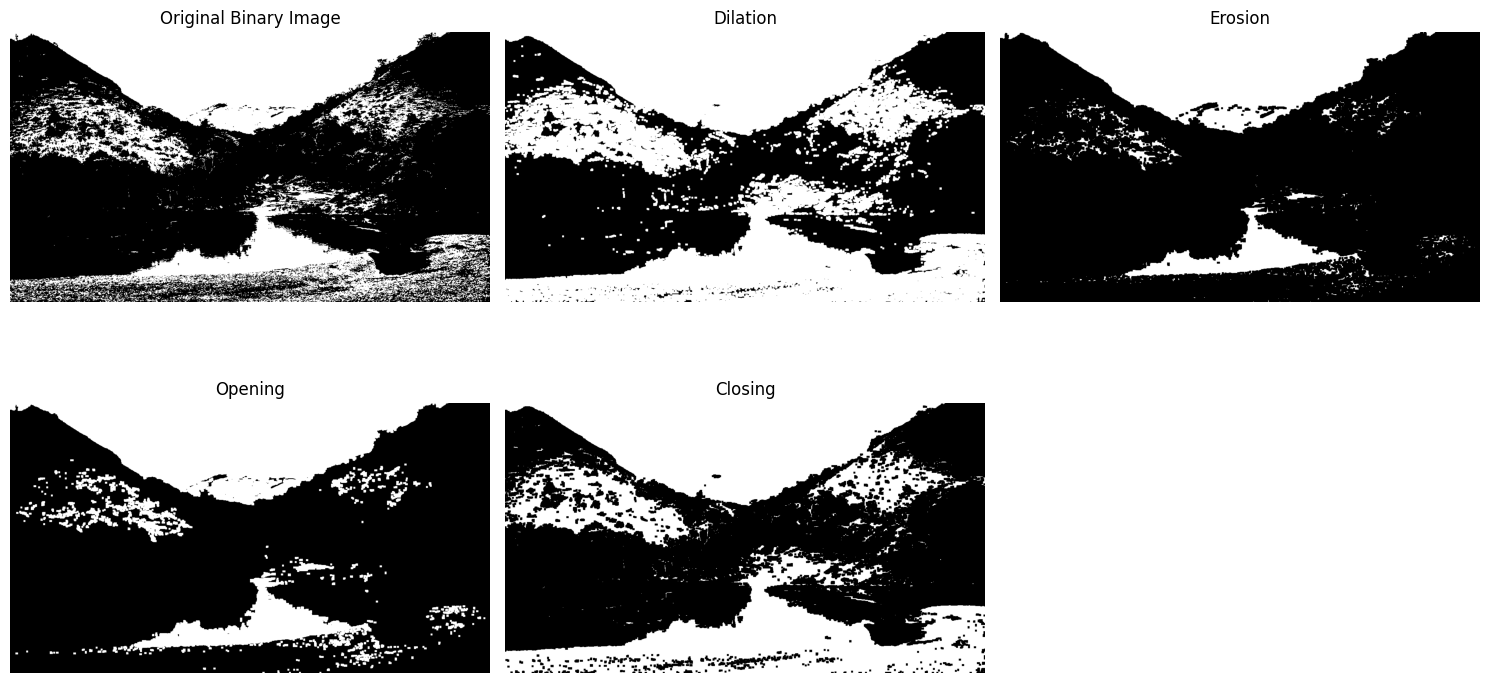

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def morphological_operations(image_path):
    # Load image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print("Error: Could not read image.")
        return

    # Threshold the image to binary
    _, binary_image = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

    # Structuring element
    kernel = np.ones((5, 5), np.uint8)

    # Morphological operations
    dilation = cv2.dilate(binary_image, kernel)
    erosion = cv2.erode(binary_image, kernel)
    opening = cv2.morphologyEx(binary_image, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(binary_image, cv2.MORPH_CLOSE, kernel)

    # Plot results
    titles = ['Original Binary Image', 'Dilation', 'Erosion', 'Opening', 'Closing']
    images = [binary_image, dilation, erosion, opening, closing]

    plt.figure(figsize=(15, 8))
    for i in range(5):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage
morphological_operations('sample-image.jpg')